In [60]:
import pandas as pd

In [80]:
train = pd.read_csv('train.csv')

In [56]:

train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [28]:
train.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [29]:
train["Cabin"] = train["Cabin"].fillna("No Cabin")

In [30]:
train.head()



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,No Cabin,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,No Cabin,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,No Cabin,S


In [31]:
train.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [32]:
train["Age"] = train["Age"].fillna(train["Age"].mean())

In [33]:
train.tail()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.00,No Cabin,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.45,No Cabin,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.000000,0,0,370376,7.75,No Cabin,Q


In [34]:
train["Sex"].unique()

<StringArray>
['male', 'female']
Length: 2, dtype: str

In [35]:
train["Sex"] = train["Sex"].replace({"M": "Male", "male": "Male"})
train["Sex"] = train["Sex"].replace({"F": "Female", "female": "Female"})

In [36]:
train_with_duplicates = pd.concat([train, train.tail(5)])

In [37]:
train_with_duplicates.tail(10)
len(train_with_duplicates)

896

In [38]:
train_with_duplicates.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
886     True
887     True
888     True
889     True
890     True
Length: 896, dtype: bool

In [39]:
train_with_duplicates.duplicated().sum()

np.int64(5)

In [40]:
train_with_duplicates_cleaned = train_with_duplicates.drop_duplicates()

In [41]:
len(train_with_duplicates_cleaned)

891

In [42]:
[1,4,5,7,4,7,6,8,14,2]


[1, 4, 5, 7, 4, 7, 6, 8, 14, 2]

In [43]:
# Identify and handle outliers in 'Fare' column
Q1 = train['Fare'].quantile(0.25)
Q3 = train['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
train = train[(train['Fare'] >= lower_bound) & (train['Fare'] <= upper_bound)]

In [44]:
train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",Male,22.000000,1,0,A/5 21171,7.2500,No Cabin,S
2,3,1,3,"Heikkinen, Miss. Laina",Female,26.000000,0,0,STON/O2. 3101282,7.9250,No Cabin,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Female,35.000000,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",Male,35.000000,0,0,373450,8.0500,No Cabin,S
5,6,0,3,"Moran, Mr. James",Male,29.699118,0,0,330877,8.4583,No Cabin,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",Male,27.000000,0,0,211536,13.0000,No Cabin,S
887,888,1,1,"Graham, Miss. Margaret Edith",Female,19.000000,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",Female,29.699118,1,2,W./C. 6607,23.4500,No Cabin,S
889,890,1,1,"Behr, Mr. Karl Howell",Male,26.000000,0,0,111369,30.0000,C148,C


In [45]:
binned_age = pd.cut(train["Age"],10,precision=1)


In [46]:
train["Age"] = binned_age
train.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",Male,"(16.3, 24.3]",1,0,A/5 21171,7.2500,No Cabin,S
2,3,1,3,"Heikkinen, Miss. Laina",Female,"(24.3, 32.3]",0,0,STON/O2. 3101282,7.9250,No Cabin,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Female,"(32.3, 40.2]",1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",Male,"(32.3, 40.2]",0,0,373450,8.0500,No Cabin,S
5,6,0,3,"Moran, Mr. James",Male,"(24.3, 32.3]",0,0,330877,8.4583,No Cabin,Q


In [53]:
custom_binned_age = pd.cut(train["Age"],bins=[0,10,20,30,40,50,60,70,80,90],precision=1)
train["Age"] = custom_binned_age
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,"(20, 30]",1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,"(30, 40]",1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,"(20, 30]",0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,"(30, 40]",1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,"(30, 40]",0,0,373450,8.0500,NaN,S


In [58]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [62]:
import matplotlib.pyplot as plt
import numpy as np



(array([608., 209.,  28.,  16.,  18.,   5.,   0.,   7.]),
 array([0., 1., 2., 3., 4., 5., 6., 7., 8.]),
 <BarContainer object of 8 artists>)

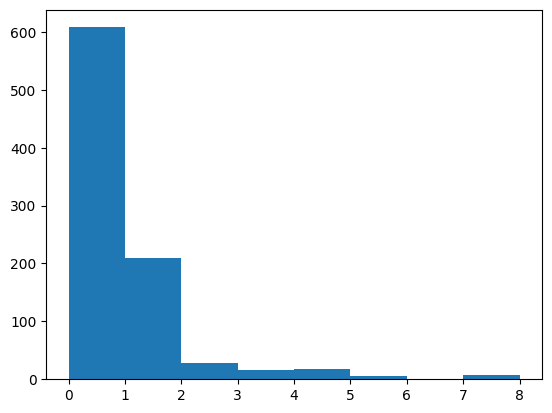

In [67]:

plt.hist(train["SibSp"], bins=8)


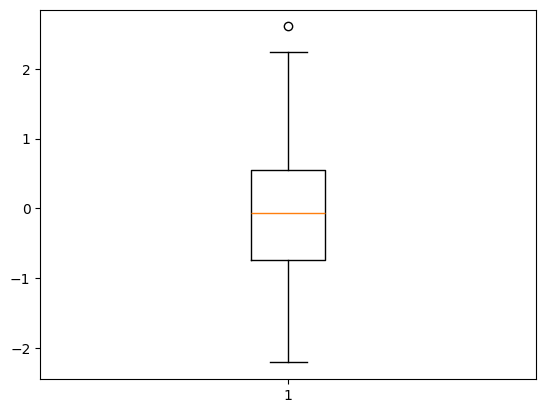

In [82]:
import numpy as np
plt.boxplot(np.random.normal(size=100))
plt.show()